# 03 - Model Training & Evaluation
## IEEE-CIS Fraud Detection

Train LightGBM model and evaluate performance:
- AUC-ROC and AUC-PR metrics
- Precision@K and Recall@K
- Feature importance analysis
- SHAP explanations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

import sys
sys.path.insert(0, '..')

from src.config import (
    TRAIN_TRANSACTION_FILE,
    TRAIN_IDENTITY_FILE,
    TARGET_COL,
    ID_COL,
    LIGHTGBM_PARAMS,
)
from src.features.build_features import FeatureEngineer

print("✅ Setup complete!")

✅ Setup complete!


## 1. Load and Prepare Data

In [ ]:
# Load Kaggle data
print("📂 Loading Kaggle data...")
train_txn = pd.read_csv(TRAIN_TRANSACTION_FILE)
train_id = pd.read_csv(TRAIN_IDENTITY_FILE)
df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"   Shape: {df.shape}")

# Apply feature engineering
print("\n🔧 Applying feature engineering...")
fe = FeatureEngineer()
df = fe.fit_transform(df)
print(f"   Features after engineering: {len(df.columns)}")

📂 Loading Kaggle data...


2026-01-20 20:31:17,182 - INFO - Fitting feature engineer...


   Shape: (590540, 434)

🔧 Applying feature engineering...


2026-01-20 20:31:18,129 - INFO -   Fitted 22 categorical encoders


   Features after engineering: 487


In [ ]:
# Prepare features for training
feature_cols = [c for c in df.columns 
                if c not in [ID_COL, TARGET_COL] 
                and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]]

X = df[feature_cols]
y = df[TARGET_COL]

print(f"📊 Dataset prepared:")
print(f"   Features: {len(feature_cols)}")
print(f"   Samples: {len(X):,}")
print(f"   Fraud rate: {y.mean():.2%}")

# Time-based split (last 20% for validation)
split_idx = int(len(X) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\n   Train: {len(X_train):,} samples")
print(f"   Val: {len(X_val):,} samples")

📊 Dataset prepared:
   Features: 452
   Samples: 590,540
   Fraud rate: 3.50%

   Train: 472,432 samples
   Val: 118,108 samples


## 2. Train LightGBM Model

In [ ]:
%%time
# Train LightGBM
print("🚀 Training LightGBM model...")

model = lgb.LGBMClassifier(**LIGHTGBM_PARAMS)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
)

print("✅ Training complete!")

🚀 Training LightGBM model...
✅ Training complete!
CPU times: user 1min 38s, sys: 36.9 s, total: 2min 15s
Wall time: 21.9 s


## 3. Model Evaluation

In [ ]:
# Get predictions
y_pred = model.predict_proba(X_val)[:, 1]

# Calculate metrics
auc_roc = roc_auc_score(y_val, y_pred)
auc_pr = average_precision_score(y_val, y_pred)

print("📊 MODEL PERFORMANCE")
print("=" * 50)
print(f"   AUC-ROC: {auc_roc:.4f}")
print(f"   AUC-PR:  {auc_pr:.4f}")
print("=" * 50)

# Precision@K and Recall@K
def precision_at_k(y_true, y_pred, k):
    top_k_idx = np.argsort(y_pred)[-k:]
    return y_true.iloc[top_k_idx].mean()

def recall_at_k(y_true, y_pred, k):
    top_k_idx = np.argsort(y_pred)[-k:]
    return y_true.iloc[top_k_idx].sum() / y_true.sum()

print("\n📈 Precision@K and Recall@K:")
for k in [100, 500, 1000, 2000, 5000]:
    p_at_k = precision_at_k(y_val, y_pred, k)
    r_at_k = recall_at_k(y_val, y_pred, k)
    print(f"   K={k:>5}: Precision={p_at_k:.2%}, Recall={r_at_k:.2%}")

📊 MODEL PERFORMANCE
   AUC-ROC: 0.9253
   AUC-PR:  0.5924

📈 Precision@K and Recall@K:
   K=  100: Precision=99.00%, Recall=2.44%
   K=  500: Precision=93.20%, Recall=11.47%
   K= 1000: Precision=92.00%, Recall=22.64%
   K= 2000: Precision=80.65%, Recall=39.69%
   K= 5000: Precision=49.92%, Recall=61.42%


## 4. ROC and PR Curves

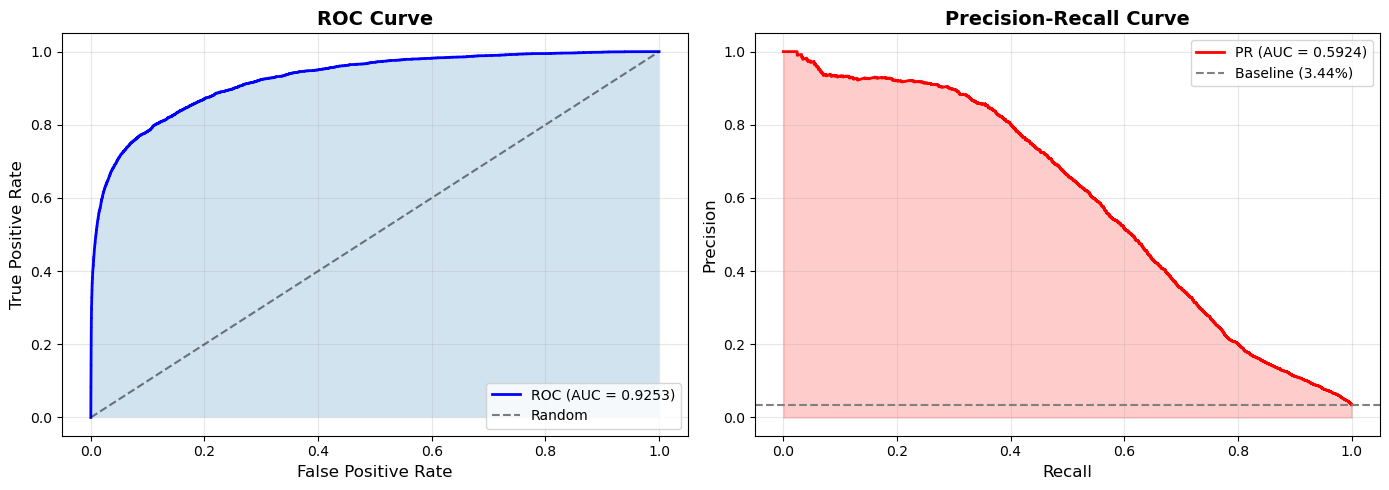

In [ ]:
# Plot ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.2)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_pred)
axes[1].plot(recall, precision, 'r-', lw=2, label=f'PR (AUC = {auc_pr:.4f})')
axes[1].axhline(y=y_val.mean(), color='gray', linestyle='--', label=f'Baseline ({y_val.mean():.2%})')
axes[1].fill_between(recall, precision, alpha=0.2, color='red')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Feature Importance

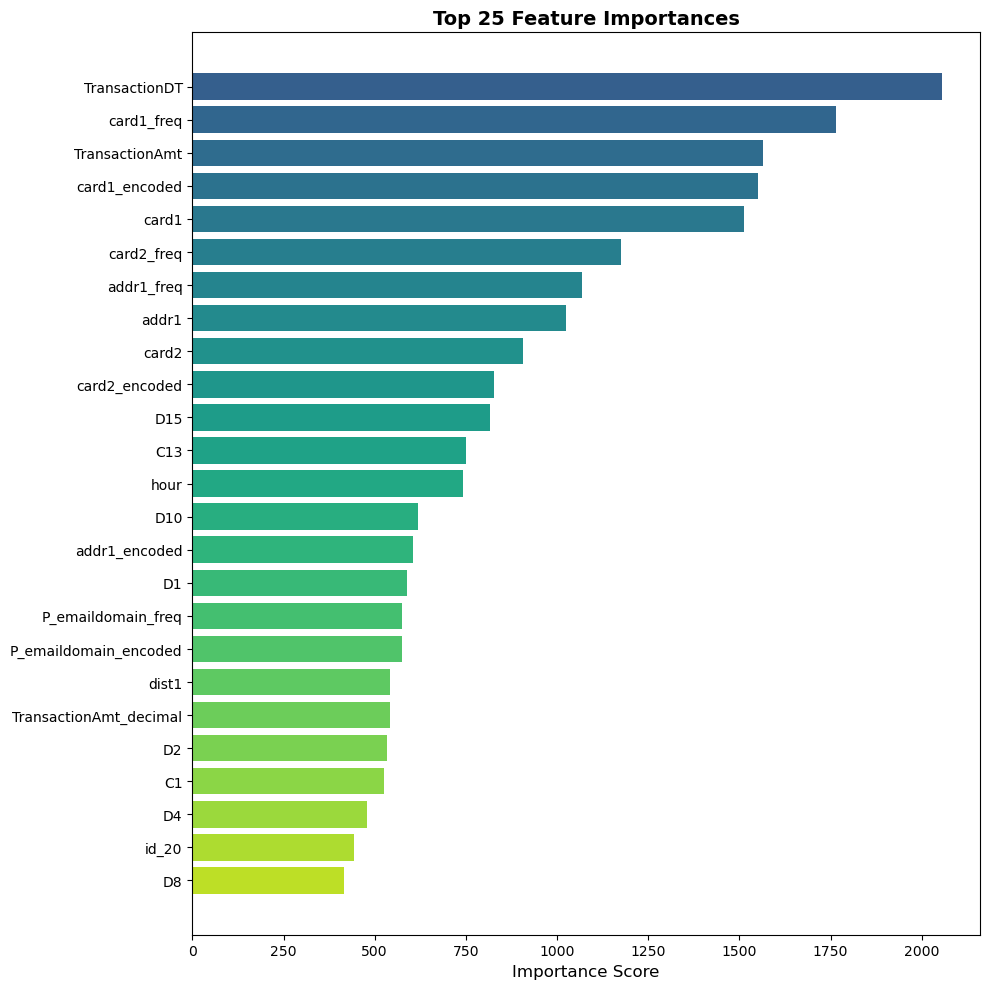

🎯 Top 10 Most Important Features:
   TransactionDT: 2057
   card1_freq: 1764
   TransactionAmt: 1566
   card1_encoded: 1552
   card1: 1512
   card2_freq: 1176
   addr1_freq: 1069
   addr1: 1024
   card2: 908
   card2_encoded: 828


In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 25
top_n = 25
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 10))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
plt.barh(range(len(top_features)), top_features['importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"🎯 Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']}: {row['importance']:.0f}")

## 6. Threshold Analysis

🎚️ Threshold Analysis:
   Finding thresholds for target recall levels...

   Recall=50%: Threshold=0.2718, Precision=66.25%
   Recall=60%: Threshold=0.1435, Precision=51.66%
   Recall=70%: Threshold=0.0687, Precision=35.29%
   Recall=80%: Threshold=0.0273, Precision=20.08%
   Recall=90%: Threshold=0.0108, Precision=11.28%


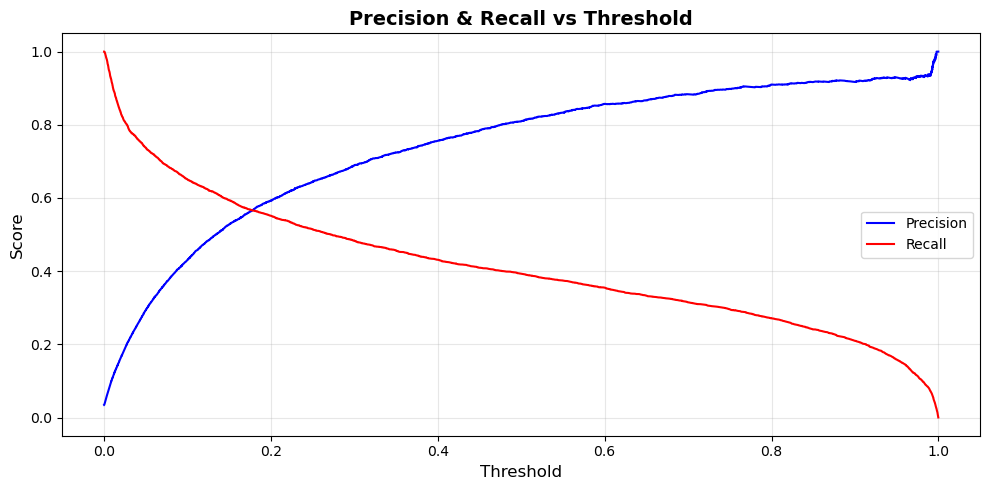

In [ ]:
# Find optimal threshold for different recall targets
print("🎚️ Threshold Analysis:")
print("   Finding thresholds for target recall levels...\n")

precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_pred)

for target_recall in [0.5, 0.6, 0.7, 0.8, 0.9]:
    idx = np.argmin(np.abs(recall_curve - target_recall))
    if idx < len(thresholds):
        thresh = thresholds[idx]
        prec = precision_curve[idx]
        print(f"   Recall={target_recall:.0%}: Threshold={thresh:.4f}, Precision={prec:.2%}")

# Plot threshold vs precision/recall
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precision_curve[:-1], 'b-', label='Precision')
ax.plot(thresholds, recall_curve[:-1], 'r-', label='Recall')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision & Recall vs Threshold', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save Model (Optional)

In [ ]:
# Save model artifacts
# Uncomment to save:

# import joblib
# from src.config import MODELS_DIR
# MODELS_DIR.mkdir(parents=True, exist_ok=True)
# joblib.dump({
#     'model': model,
#     'feature_engineer': fe,
#     'feature_cols': feature_cols,
# }, MODELS_DIR / 'fraud_model.joblib')
# print(f"✅ Model saved to {MODELS_DIR / 'fraud_model.joblib'}")

print("💡 To train model via CLI, run: make train")
print("\n" + "=" * 50)
print("📋 SUMMARY")
print("=" * 50)
print(f"   AUC-ROC: {auc_roc:.4f}")
print(f"   AUC-PR:  {auc_pr:.4f}")
print(f"   Top Feature: {feature_importance.iloc[0]['feature']}")
print("=" * 50)

💡 To train model via CLI, run: make train

📋 SUMMARY
   AUC-ROC: 0.9253
   AUC-PR:  0.5924
   Top Feature: TransactionDT
